In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from elpv_dataset.utils import load_dataset

images, defect_probability, cell_type = load_dataset()

In [2]:
def extract_features(image):
    mean_brightness = np.mean(image)
    contrast = np.std(image)

    edges = cv2.Canny(image, 50, 150)
    edge_density = np.mean(edges > 0)

    dark_pixel_ratio = np.mean(image < 50)

    return {
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "edge_density": edge_density,
        "dark_pixel_ratio": dark_pixel_ratio
    }

In [3]:
feature_rows = [
    extract_features(image)
    for image in images
]

features = pd.DataFrame(feature_rows)

features["defect_probability"] = defect_probability
features["cell_type"] = cell_type

features.head()

,mean_brightness,contrast,edge_density,dark_pixel_ratio,defect_probability,cell_type
0,72.469667,17.068925,0.000000,0.122967,1.0,mono
1,84.836144,20.891564,0.000000,0.092678,1.0,mono
2,76.530200,16.200018,0.000000,0.099733,1.0,mono
3,90.565211,21.897937,0.000000,0.060467,0.0,mono
4,117.486189,38.802465,0.008111,0.084978,1.0,mono


In [4]:
features.info()
features.describe().round(3)

<class 'pandas.DataFrame'>
RangeIndex: 2624 entries, 0 to 2623
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_brightness     2624 non-null   float64
 1   contrast            2624 non-null   float64
 2   edge_density        2624 non-null   float64
 3   dark_pixel_ratio    2624 non-null   float64
 4   defect_probability  2624 non-null   float64
 5   cell_type           2624 non-null   str    
dtypes: float64(5), str(1)
memory usage: 123.1 KB


,mean_brightness,contrast,edge_density,dark_pixel_ratio,defect_probability
count,2624.000,2624.000,2624.000,2624.000,2624.000
mean,152.172,29.084,0.029,0.016,0.337
std,27.904,7.304,0.014,0.071,0.435
min,13.812,4.732,0.000,0.000,0.000
25%,137.046,23.735,0.021,0.000,0.000
50%,156.381,28.597,0.032,0.000,0.000
75%,170.571,33.495,0.034,0.011,1.000
max,228.239,89.211,0.082,0.999,1.000


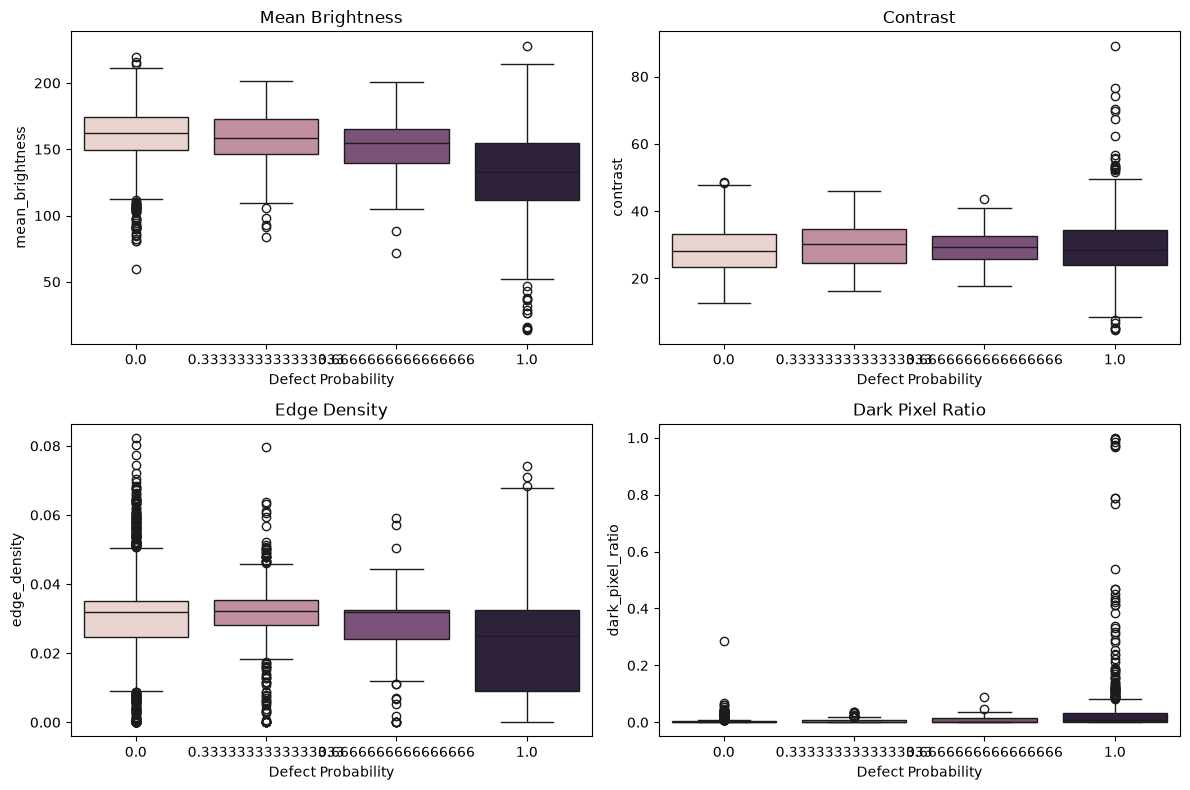

In [5]:
feature_names = [
    "mean_brightness",
    "contrast",
    "edge_density",
    "dark_pixel_ratio"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for feature_name, ax in zip(feature_names, axes.flat):
    sns.boxplot(
        data=features,
        x="defect_probability",
        y=feature_name,
        hue="defect_probability",
        legend=False,
        ax=ax
    )

    ax.set_title(feature_name.replace("_", " ").title())
    ax.set_xlabel("Defect Probability")

plt.tight_layout()

plt.savefig(
    "../reports/figures/engineered_features_by_defect.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()